In [1]:
import random
import torch

### 3.2.1 生成数据集

In [48]:
def synthetic_data(w, b, num_examples):     #@save
    """生成数据集(y=Xw+b+噪声)"""
    # 使用torch.normal()正态分布函数生成符合正态分布的随机数
    # 均值为0，标准差为1，输出张量形状为(num_examples, len(w))
    X = torch.normal(0, 1, (num_examples, len(w)))
    # 使用torch.matmul(X, w)计算矩阵乘法，再加上偏置(bias): b
    y = torch.matmul(X, w) + b
    # 添加随机噪声，使用torch.normal()函数生成符合正态分布的随机噪声值
    # 均值为0，标准差为0.01，输出张量形状与y的形状一致
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [20]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [21]:
print('features: ', features[0], '\nlabel: ', labels[0])

features:  tensor([ 1.7273, -0.6621]) 
label:  tensor([9.9009])


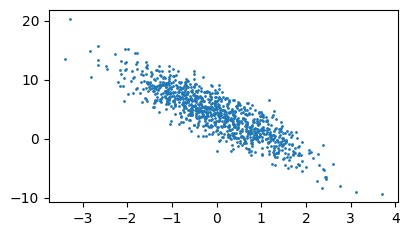

In [22]:
# 画图
from matplotlib import pyplot as plt

plt.figure(figsize=(4.5, 2.5))
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)
plt.show()

### 3.2.2 读取数据集

In [26]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)                    # num_examples为features的长度，这里是1000
    indices = list(range(num_examples))             # indices 为 0 - 999 的list列表[0, 1, 2, 3, ..., 999]
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)                         # 将indices列表随机打乱
    for i in range(0, num_examples, batch_size):    # 带步长的循环，从0开始，到num_examples结束（不包含），步长为batch_size，即每次增加batch_size
        # batch_indices从打乱顺序之后的indices中选择从i开始，到min(i + batch_size, num_examples)结束的数字作为索引位置
        # 假设batch_size = 10，每次循环增加10
        # i = 0时，batch_indices = torch.tensor(indices[0: 10])
        # i = 10时，batch_indices = torch.tensor(indices[10， 20])
        # 到最后一次循环时，如果num_examples < i + batch_size, 则batch_indices = torch.tensor(indices[i, num_examples])
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [27]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.7262, -0.9122],
        [-0.5190,  0.9133],
        [ 1.0740, -1.1608],
        [-0.1439, -1.6944],
        [ 0.0238, -2.1587],
        [-0.3809,  0.7578],
        [ 0.7854, -1.7868],
        [ 0.4742,  0.1617],
        [ 1.2254, -0.1350],
        [ 0.1838,  1.1016]]) 
 tensor([[10.7674],
        [ 0.0338],
        [10.3162],
        [ 9.6730],
        [11.5995],
        [ 0.8502],
        [11.8489],
        [ 4.5991],
        [ 7.0857],
        [ 0.8145]])


- 这里返回用yield, 而不是return：

| 特性 | 普通函数（return） | 生成器函数（yield） |
|------|-------------------|-------------------|
| 内存使用 | 一次性加载所有数据 | 按需加载，内存友好 |
| 执行时机 | 一次性执行完毕 | 惰性执行，按需生成 |
| 返回值 | 返回完整结果 | 返回生成器对象 |
| 状态保持 | 每次调用重新开始 | 保持内部状态 |
| 适合场景 | 小数据集 | 大数据集、流式数据 |

### 3.2.3 初始化模型参数

In [29]:
# 从均值为0、标准差为0.01的正态分布中抽取随机数来初始化权重，并将偏置初始化为0
# 在初始化之后，我们的任务是更新这些参数，直到这些参数足以拟合我们的数据
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 3.2.4 定义模型

In [30]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

### 3.2.5 定义损失函数
需要将真实值y的形状转换为和预测值y_hat的形状相同

In [44]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 3.2.6 定义优化算法
下面的函数实现小批量随机梯度下降更新，该函数接收模型参数集合、学习率和批量大小作为输入。每一步更新的大小由学习率lr决定。

In [45]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():                                       # 禁用梯度计算和追踪，为了减少内存使用，提高计算速度，防止更新操作被错误de追踪
        for param in params:                                    # 遍历所有参数，(通常情况下params=[w,b])
            # 核心参数更新公式，将参数往梯度的反方向更新（梯度下降），根据学习率(lr)来更新
            # 因为计算的梯度是小批量数据集的总梯度，所以需要除以batch_size
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 3.2.7 训练
我们将执行以下迭代：
(1) 初始化参数
(2) 重复以下训练，直到完成：
- 计算梯度$\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
- 更新参数$(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$

在每个*迭代周期*（epoch）中，我们使用`data_iter`函数遍历整个数据集，
并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。
这里的迭代周期个数`num_epochs`和学习率`lr`都是超参数，分别设为3和0.03。

In [46]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # X和y的小批量损失, (loss = squared_loss, net = linreg, 这段代码等价于 l = squared_loss(linreg(X, w, b), y)
        # 首先使用之前已经随机初始化之后的w和b，套用线性回归模型，计算预测的y_hat值，然后再计算预测的y_hat和真实的y之间的损失值
        l = loss(net(X, w, b), y)
        # 因为l的形状是(batch_size, 1), 而不是一个标量
        # l中的所有元素被加到一起，并以此计算关于[w, b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)                     # 使用参数的梯度更新参数

    # 每一轮(epoch)之后，w和b的参数已经更新完成了，下面计算训练损失
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000051
epoch 2, loss 0.000051
epoch 3, loss 0.000051


In [47]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([1.7524e-05, 2.3675e-04], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0008], grad_fn=<RsubBackward1>)
